# Project 2 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You can then choose from one of the three themes for part 2.

You will be working with a subset of the Cats and Dogs data set (and maybe a subset of the MNIST data set).

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke".

In [1]:
# In the last project we have already seen example of the MNIST data set. Here we take a look at Cats and Dogs

import pandas as pd 

PATHIM = "cnd_large//images.csv" 
PATHLB = "cnd_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

# Check sizes
print(f"'images' size: {images.shape}")
print(f"'labels' size: {labels.shape}")

# Number of classes:
print(f"Classes {labels["label"].unique()}")

'images' size: (10000, 4096)
'labels' size: (10000, 1)
Classes [0 1]


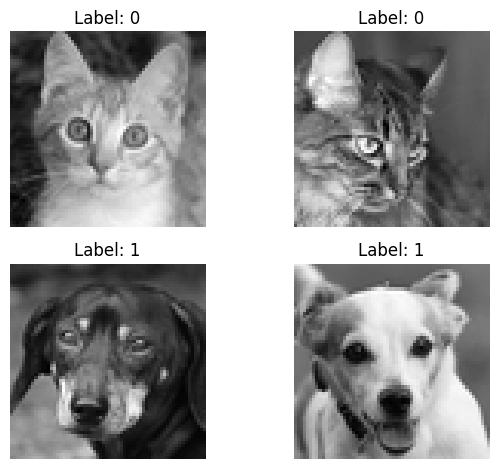

In [2]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

#Visualize some images (take two from each class):
catidx = np.where(labels == 0)[0]
dogidx = np.where(labels == 1)[0]

n_samples = 2

catsample = np.random.choice(catidx, size = n_samples, replace = False)
dogsample = np.random.choice(dogidx, size = n_samples, replace = False)

idx = np.concatenate([catsample, dogsample])
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(2, 2)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(64,64)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

In [3]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = images
y = labels

# Fixed train/test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

n_train_full = X_train_full.shape[0]
fractions = np.linspace(1, 0.1, 10)

results = { "svd": [], "shrink": [] }
rng = np.random.RandomState(0)

for f in fractions:
    n_keep = int(n_train_full * f)
    idx = rng.choice(n_train_full, n_keep, replace=False)
    X_train = X_train_full[idx]
    y_train = y_train_full[idx]

    # SVD solver (fastest)
    try:
        acc_svd = accuracy_score(y_test,
            LinearDiscriminantAnalysis(solver="svd").fit(X_train, y_train).predict(X_test)
        )
    except:
        acc_svd = np.nan

    # Regularized / shrunk LDA (fast, avoids singularity)
    try:
        acc_shrink = accuracy_score(y_test,
            LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
            .fit(X_train, y_train)
            .predict(X_test)
        )
    except:
        acc_shrink = np.nan

    results["svd"].append((f, acc_svd))
    results["shrink"].append((f, acc_shrink))

# Print
for name in results:
    print(f"\n== {name} ==")
    for f, acc in results[name]:
        print(f"Fraction {f:.2f}: acc = {acc:.3f}")


== svd ==
Fraction 1.00: acc = 0.689
Fraction 0.90: acc = 0.670
Fraction 0.80: acc = 0.648
Fraction 0.70: acc = 0.606
Fraction 0.60: acc = 0.545
Fraction 0.50: acc = 0.599
Fraction 0.40: acc = 0.660
Fraction 0.30: acc = 0.674
Fraction 0.20: acc = 0.723
Fraction 0.10: acc = 0.738

== shrink ==
Fraction 1.00: acc = 0.756
Fraction 0.90: acc = 0.746
Fraction 0.80: acc = 0.745
Fraction 0.70: acc = 0.747
Fraction 0.60: acc = 0.733
Fraction 0.50: acc = 0.728
Fraction 0.40: acc = 0.729
Fraction 0.30: acc = 0.710
Fraction 0.20: acc = 0.726
Fraction 0.10: acc = 0.730


# Part 1

*Everyone should do this task.*

For the first part, use the provided Cats and Dogs data set.

Use at least 3 different classifiers and at least 2 feature selection methods.

For example, you can use filtering or wrappers in conjuction with any of the classifiers (using e.g. threshholds on the importance, t-tests/F-tests or CV-error with forward selection etc). I.e., for the filtering method you choose a test or scoring mechanism and use CV to determine the optimal threshold.

For the wrapper method you choose, e.g., forward selection or backward selection, CV is used when to stop adding features. Here, the scoring mechanism to decide which order to drop/add features can be based on drop/increase in predictive performance, importance metrics, etc.

The embedding methods we have talked about in class is lasso/elastic net which is used with multinomial/logistic regression. For the embedding methods, CV is used to choose the penalty parameter.

Note, you can also use a combination of techniques - perhaps you want to filter the features before you use wrappers or embedding methods?

Questions to answer

1. Using CV, determine how many features (pixels) you need for classification. Does the optimal number of features differ between the approaches?

2. Which pixels are selected? Does this differ between the approaches/classification methods? (Can you think of why?)

3. Repeat the above a few times - is the selection stable? (meaning the number of features needed and/or which pixels are chosen is roughly the same across multiple runs).



In [4]:
# 3 Classifiers
# 2 feature selection metods
#eg. filtering or wrappers. ie. For the filtering method choose a test and use CV to determine optimal threshold
#For wrapper method chosen: eg. forward or backward selection. CV is used to determine when 


#Classifiers:
# - Tree-based methods: Random forest
# -Clustering: k-means
# -Model-based classification: Nearest centroid

#Feature selection methods: 

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif #?
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

In [6]:
#1. Using CV, determine how many features (pixels) you need for classification. 
# Does the optimal number of features differ between the approaches?


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


F1 score on test set: 0.7908396946564885
the best optimiser is Pipeline(steps=[('filter', SelectKBest(k=200)),
                ('classifier', RandomForestClassifier(random_state=42))]) with score 0.7885557275246056 and parameters {'filter__k': 200, 'classifier__n_estimators': 100}


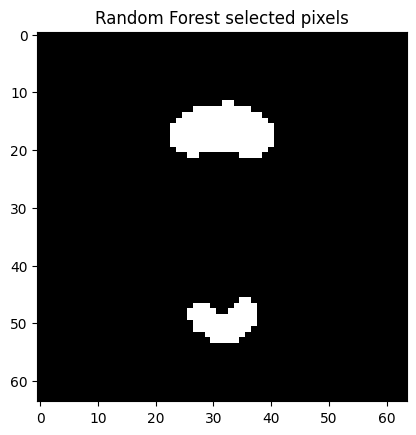

C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


F1 score on test set: 0.7268195413758723
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()), ('filter', SelectKBest(k=200)),
                ('embedded',
                 SelectFromModel(estimator=LogisticRegression(penalty='l1',
                                                              random_state=42,
                                                              solver='liblinear'),
                                 threshold='median')),
                ('classifier', SVC(C=np.float64(0.01), kernel='linear'))]) with score 0.7290210941883365 and parameters {'filter__k': 200, 'classifier__C': np.float64(0.01)}


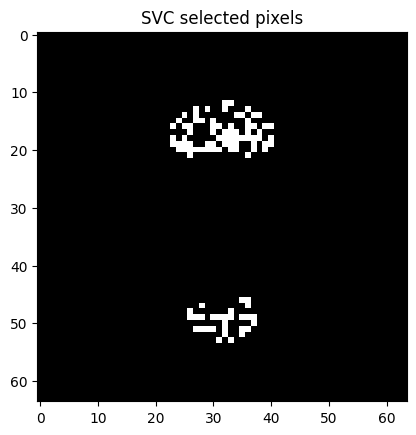

C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


F1 score on test set: 0.7467811158798283
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()), ('filter', SelectKBest(k=200)),
                ('classifier', KNeighborsClassifier(n_neighbors=7))]) with score 0.7534903941343108 and parameters {'filter__k': 200, 'classifier__n_neighbors': 7}


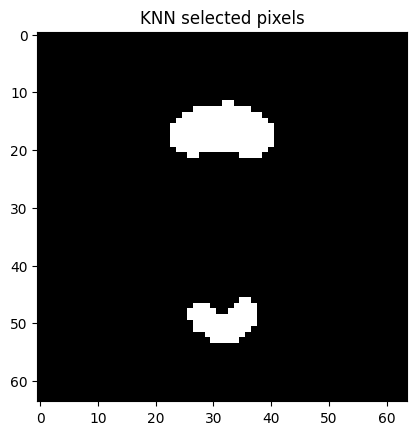

C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


F1 score on test set: 0.8072942336126171
the best optimiser is Pipeline(steps=[('filter', SelectKBest(k=200)),
                ('classifier', RandomForestClassifier(random_state=123))]) with score 0.7916659133751879 and parameters {'filter__k': 200, 'classifier__n_estimators': 100}


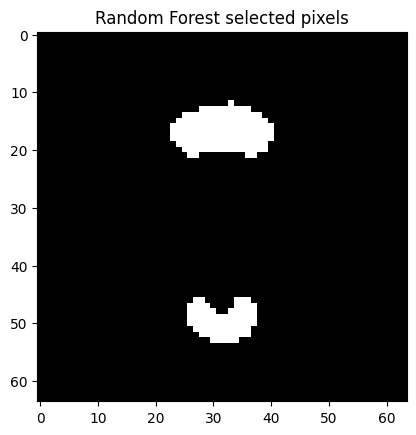

C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


F1 score on test set: 0.7447535383113714
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()), ('filter', SelectKBest(k=200)),
                ('embedded',
                 SelectFromModel(estimator=LogisticRegression(penalty='l1',
                                                              random_state=123,
                                                              solver='liblinear'),
                                 threshold='median')),
                ('classifier', SVC(C=np.float64(0.01), kernel='linear'))]) with score 0.7268385664162719 and parameters {'filter__k': 200, 'classifier__C': np.float64(0.01)}


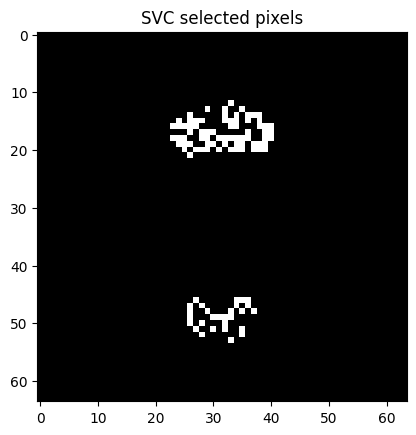

C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


F1 score on test set: 0.7713987473903967
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()), ('filter', SelectKBest(k=200)),
                ('classifier', KNeighborsClassifier(n_neighbors=7))]) with score 0.7550980526111845 and parameters {'filter__k': 200, 'classifier__n_neighbors': 7}


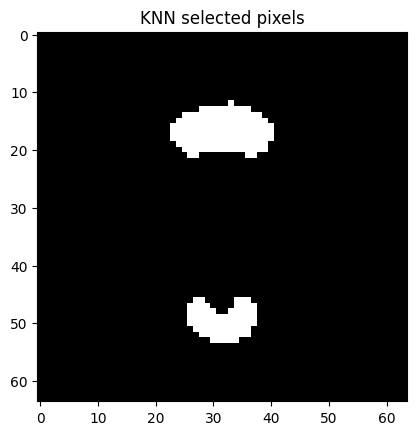

C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


F1 score on test set: 0.7916666666666666
the best optimiser is Pipeline(steps=[('filter', SelectKBest(k=200)),
                ('classifier', RandomForestClassifier(random_state=32))]) with score 0.7947866223411416 and parameters {'filter__k': 200, 'classifier__n_estimators': 100}


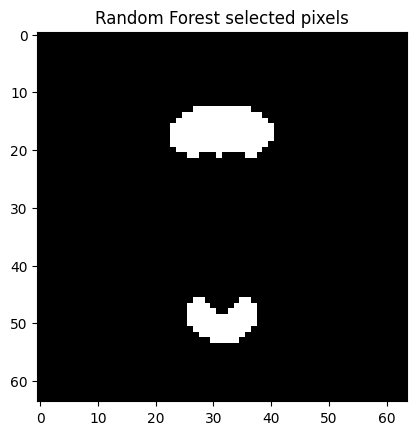

C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


F1 score on test set: 0.7384007897334649
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()), ('filter', SelectKBest(k=200)),
                ('embedded',
                 SelectFromModel(estimator=LogisticRegression(penalty='l1',
                                                              random_state=32,
                                                              solver='liblinear'),
                                 threshold='median')),
                ('classifier', SVC(C=np.float64(0.01), kernel='linear'))]) with score 0.729271166848967 and parameters {'filter__k': 200, 'classifier__C': np.float64(0.01)}


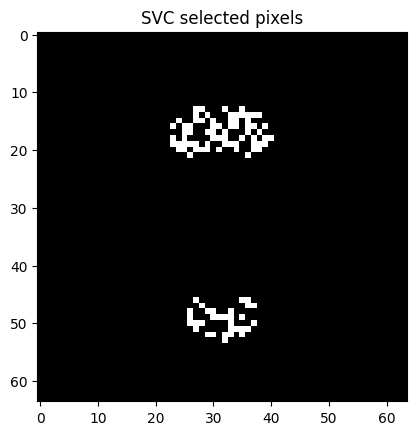

C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


F1 score on test set: 0.7559055118110236
the best optimiser is Pipeline(steps=[('scaler', StandardScaler()), ('filter', SelectKBest(k=200)),
                ('classifier', KNeighborsClassifier(n_neighbors=7))]) with score 0.7477755448252407 and parameters {'filter__k': 200, 'classifier__n_neighbors': 7}


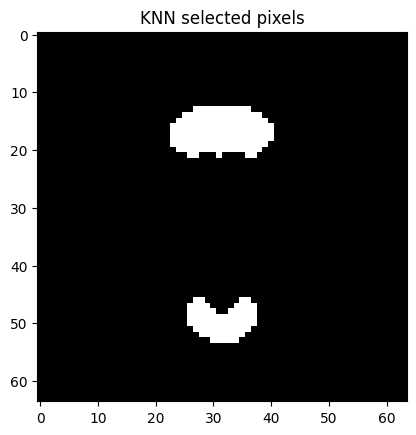

In [ ]:

B = 5
k = [50, 100, 200]
p_val = 5
#Function to calculate the new x_train and x_test with fewer patterns

num_trees = [50, 100]

models = {"RandomForestClassifier": {"params": {"classifier__n_estimators": num_trees, "filter__k": k}, "results": []}, "SVC": {"params": {"classifier__C": np.logspace(-2, 2, 3), "filter__k": k}, "results": []}, "KNN": {"params": {"classifier__n_neighbors": [3, 5, 7], "filter__k": k}, "results": []}}


def classifying(random_seed, models_loc):
#X_train_new, x_test_new, x_val_new, y_test_new, y_train_new, y_val_new = get_projected(images, labels, random_seed, train_fraction = 0.6, val_fraction = 0.2)
    X_train, X_test, y_train, y_test = train_test_split(
        images,
        labels,
        test_size=0.2,
        stratify=labels,
        random_state=random_seed
    )

    #Raandom forest

    pipe_random_forest = Pipeline([
        ("filter", SelectKBest(score_func = f_classif)), #filter
        #("embedded", SelectFromModel(LogisticRegression(l1_ratio=1, solver='liblinear', random_state=random_seed), threshold = "median")), #embedded
        ("classifier", RandomForestClassifier(random_state=random_seed))
        ])


    #max_depth=10, min_samples_split=10, min_samples_leaf =5,
    #max_features='sqrt', random_state=123, n_jobs = -1
    opt = RandomizedSearchCV(
        pipe_random_forest,
        param_distributions = models_loc["RandomForestClassifier"]["params"], 
        n_iter=10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = 0),
        scoring = "f1",
        n_jobs=2
    )
    opt.fit(X_train, y_train)
    y_pred = opt.predict(X_test)
    f1_rf = f1_score(y_test, y_pred)
    print(f"F1 score on test set: {f1_rf}")
    #print(opt.cv_results_)
    print(f"the best optimiser is {opt.best_estimator_} with score {opt.best_score_} and parameters {opt.best_params_}")
    final_mask = opt.best_estimator_.named_steps["filter"].get_support()
    plt.figure()
    plt.imshow(final_mask.reshape(64,64), cmap="gray")
    plt.title("Random Forest selected pixels")
    plt.show()

    models_loc["RandomForestClassifier"]["results"].append((opt.best_estimator_, opt.best_score_, opt.best_params_, f1_rf, final_mask))


    #SVC
    pipe_svc = Pipeline([
        ("scaler", StandardScaler()),
        ("filter", SelectKBest(score_func = f_classif)), #filter
        ("embedded", SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=random_seed), threshold = "median")), #embedded
        ("classifier", SVC(kernel='linear'))
        ])

    opt_svc = RandomizedSearchCV(
        pipe_svc,
        param_distributions = models_loc["SVC"]["params"], 
        n_iter=10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = 0),
        scoring = "f1",
        n_jobs=2
    )
    opt_svc.fit(X_train, y_train)
    y_pred_svc = opt_svc.predict(X_test)
    f1_svc = f1_score(y_test, y_pred_svc)
    print(f"F1 score on test set: {f1_svc}")
    #print(opt_svc.cv_results_)
    print(f"the best optimiser is {opt_svc.best_estimator_} with score {opt_svc.best_score_} and parameters {opt_svc.best_params_}")
    mask_svc = opt_svc.best_estimator_.named_steps["filter"].get_support()
    embedded_svc = opt_svc.best_estimator_.named_steps["embedded"].get_support()
    final_mask_svc = np.zeros_like(mask_svc)
    final_mask_svc[np.where(mask_svc)[0]] = embedded_svc
    plt.figure()
    plt.imshow(final_mask_svc.reshape(64,64), cmap="gray")
    plt.title("SVC selected pixels")
    plt.show()
    models_loc["SVC"]["results"].append((opt_svc.best_estimator_, opt_svc.best_score_, opt_svc.best_params_, f1_svc, final_mask_svc))


    #KNN
    pipe_knn = Pipeline([
        ("scaler", StandardScaler()),
        ("filter", SelectKBest(score_func = f_classif)), #filter
        #("embedded", SelectFromModel(LogisticRegression(l1_ratio=1, solver='liblinear', random_state=random_seed), threshold = "median")), #embedded
        ("classifier", KNeighborsClassifier())
        ])
    opt_knn = RandomizedSearchCV(
        pipe_knn,
        param_distributions = models_loc["KNN"]["params"], 
        n_iter=10,
        cv = StratifiedKFold(n_splits=3, shuffle = True, random_state = 0),
        scoring = "f1",
        n_jobs=2
    )
    opt_knn.fit(X_train, y_train)
    y_pred_knn = opt_knn.predict(X_test)
    f1_knn = f1_score(y_test, y_pred_knn)
    print(f"F1 score on test set: {f1_knn}")
    #print(opt_knn.cv_results_)
    print(f"the best optimiser is {opt_knn.best_estimator_} with score {opt_knn.best_score_} and parameters {opt_knn.best_params_}")
    final_mask_knn = opt_knn.best_estimator_.named_steps["filter"].get_support()
    plt.figure()
    plt.imshow(final_mask_knn.reshape(64,64), cmap="gray")
    plt.title("KNN selected pixels")
    plt.show()
    models_loc["KNN"]["results"].append((opt_knn.best_estimator_, opt_knn.best_score_, opt_knn.best_params_, f1_knn, final_mask_knn))

    return models_loc 

models = classifying(42, models)
models = classifying(123, models)
models = classifying(32, models)

In [8]:
f1s = [[0.824, 0.836, 0.841], [0.767, 0.764 ], [0.739, 0.767]]

C:\Users\jeys_\AppData\Local\Temp\ipykernel_29908\1084793331.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(f1s, labels = ["RF", "SVC", "KNN"])


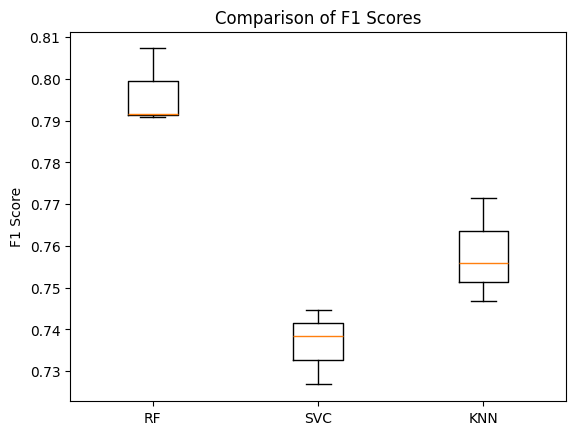

In [9]:
masks = [[], [], []]
f1s = [[], [], []]
for i in range(3):
    _, _, _, f1_rf, mask_rf = models["RandomForestClassifier"]["results"][i]
    masks[0].append(mask_rf)
    f1s[0].append(f1_rf)
    _, _, _, f1_svc, mask_svc = models["SVC"]["results"][i]
    masks[1].append(mask_svc)
    f1s[1].append(f1_svc)
    _, _, _, f1_knn, mask_knn = models["KNN"]["results"][i]
    masks[2].append(mask_knn)
    f1s[2].append(f1_knn)

"""
stability_map_rf = masks[0][0] + masks[0][1] + masks[0][2]
plt.figure()
plt.imshow(stability_map_rf.reshape(64,64), cmap="gray")
plt.title("Stability map for Random Forest")
plt.show()

stability_map_svc = masks[1][0] + masks[1][1] + masks[1][2]
plt.figure()
plt.imshow(stability_map_svc.reshape(64,64), cmap="gray")
plt.title("Stability map for SVC")
plt.show()

stability_map_knn = masks[2][0] + masks[2][1] + masks[2][2]
plt.figure()
plt.imshow(stability_map_knn.reshape(64,64), cmap="gray")
plt.title("Stability map for KNN")
plt.show()
"""

plt.boxplot(f1s, labels = ["RF", "SVC", "KNN"])
plt.ylabel("F1 Score")
plt.title("Comparison of F1 Scores")
plt.show()


## Part 2 - Themes
Choose ***one*** theme of the three and perform ***all*** tasks as described in this theme.

### Theme 1 - Correlated noise features
Use the Cats and Dogs data set. 

Add (independent) Gaussian noise to a subset of the features. Increase the percentage of the features. 
How is classification accuracy affected for the different methods?

Now, do the same but with correlated Gaussian noise. 
How do the different methods handle correlated noise features? 
At what noise level do the methods break down? 

### Theme 2 - Image flip
Use the Cats and Dogs data set. 

Flip half of the images (half of the cats and half of the dogs) upside down. 
Perform the same steps as in Part 1. 

How is feature importance affected by the flipping?

### Theme 3 - Heterogeneous classes
Use the MNIST data set. 

Create heterogeneous classes by flipping half of the images in a class. 
1. First, flip images in class 0.
2. Then, flip images in class 4 (and revert the changes from the previous step).
3. Lastly, flip images in one of class 2, 5, 6 or 9 (and revert the changes from the previous step).

Perform the same steps as in Part 1 for the three sets. 

Present confusion matrices and other appropriate plots. What happened? 

In [ ]:
# Part 2 Theme 1 - Correlated noise features

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel, SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

noise_fractions = [0.3]
noise_types = ["correlated"]
random_seeds = [42, 123, 32]

print("Noise fractions:", noise_fractions)
print("Noise types:", noise_types)
print("Repeated seeds:", random_seeds)

def make_l1_selector(random_seed):
    return SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=2000,
            random_state=random_seed
        ),
        threshold="median"
    )


def get_full_pixel_mask(filter_mask, embedded_mask):
    final_mask = np.zeros_like(filter_mask)
    final_mask[np.where(filter_mask)[0]] = embedded_mask
    return final_mask


def get_model_pipelines(random_seed):
    k_values = [50, 100]
    num_trees = [50, 100]

    models = {
        "RandomForestClassifier": {
            "pipeline": Pipeline([
                ("filter", SelectKBest(score_func=f_classif)),
                #("embedded", make_l1_selector(random_seed)),
                ("classifier", RandomForestClassifier(random_state=random_seed))
            ]),
            "params": {
                "classifier__n_estimators": num_trees,
                "filter__k": k_values
            },
        },
        "SVC": {
            "pipeline": Pipeline([
                ("scaler", StandardScaler()),
                ("filter", SelectKBest(score_func=f_classif)),
                ("embedded", make_l1_selector(random_seed)),
                ("classifier", SVC(kernel="linear"))
            ]),
            "params": {
                "classifier__C": np.logspace(-2, 2, 3),
                "filter__k": k_values
            },
        },
        "KNN": {
            "pipeline": Pipeline([
                ("scaler", StandardScaler()),
                ("filter", SelectKBest(score_func=f_classif)),
                #("embedded", make_l1_selector(random_seed)),
                ("classifier", KNeighborsClassifier())
            ]),
            "params": {
                "classifier__n_neighbors": [3, 5, 7],
                "filter__k": k_values
            },
        },
    }

    return models

Noise fractions: [0.1, 0.3, 0.5]
Noise types: ['independent', 'correlated']
Repeated seeds: [42, 123, 32]


In [11]:
#independent noise helpers
def add_independent_noise(X, noise_fraction, noise_sigma=60, random_seed=42):
    rng = np.random.default_rng(random_seed)
    X_noisy = X.astype(float).copy()

    n_features = X_noisy.shape[1]
    n_noise = int(n_features * noise_fraction)
    noise_pixels = rng.choice(n_features, size=n_noise, replace=False)

    noise = rng.normal(0, noise_sigma, size=(X_noisy.shape[0], n_noise))
    X_noisy[:, noise_pixels] = X_noisy[:, noise_pixels] + noise
    X_noisy = np.clip(X_noisy, 0, 255)

    return X_noisy, noise_pixels


def add_independent_noise_to_pixels(X, noise_pixels, noise_sigma=60, random_seed=42):
    rng = np.random.default_rng(random_seed)
    X_noisy = X.astype(float).copy()

    noise = rng.normal(0, noise_sigma, size=(X_noisy.shape[0], len(noise_pixels)))
    X_noisy[:, noise_pixels] = X_noisy[:, noise_pixels] + noise
    X_noisy = np.clip(X_noisy, 0, 255)

    return X_noisy

#correlated noise helpers
def add_correlated_noise(X, noise_fraction, noise_sigma=60, random_seed=42):
    rng = np.random.default_rng(random_seed)
    X_noisy = X.astype(float).copy()

    n_features = X_noisy.shape[1]
    n_noise = int(n_features * noise_fraction)
    noise_pixels = rng.choice(n_features, size=n_noise, replace=False)

    shared_noise = rng.normal(0, noise_sigma, size=(X_noisy.shape[0], 1))
    small_noise = rng.normal(
        0,
        noise_sigma * 0.25,
        size=(X_noisy.shape[0], n_noise)
    )

    X_noisy[:, noise_pixels] = X_noisy[:, noise_pixels] + shared_noise + small_noise
    X_noisy = np.clip(X_noisy, 0, 255)

    return X_noisy, noise_pixels


def add_correlated_noise_to_pixels(X, noise_pixels, noise_sigma=60, random_seed=42):
    rng = np.random.default_rng(random_seed)
    X_noisy = X.astype(float).copy()

    shared_noise = rng.normal(0, noise_sigma, size=(X_noisy.shape[0], 1))
    small_noise = rng.normal(
        0,
        noise_sigma * 0.25,
        size=(X_noisy.shape[0], len(noise_pixels))
    )

    X_noisy[:, noise_pixels] = X_noisy[:, noise_pixels] + shared_noise + small_noise
    X_noisy = np.clip(X_noisy, 0, 255)

    return X_noisy

Running: independent 0.1 RandomForestClassifier
Running: independent 0.1 SVC


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Running: independent 0.1 KNN
Running: independent 0.1 RandomForestClassifier
Running: independent 0.1 SVC


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Running: independent 0.1 KNN
Running: independent 0.1 RandomForestClassifier
Running: independent 0.1 SVC


...

Running: correlated 0.5 KNN
Running: correlated 0.5 RandomForestClassifier
Running: correlated 0.5 SVC


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Running: correlated 0.5 KNN
Running: correlated 0.5 RandomForestClassifier
Running: correlated 0.5 SVC


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Running: correlated 0.5 KNN


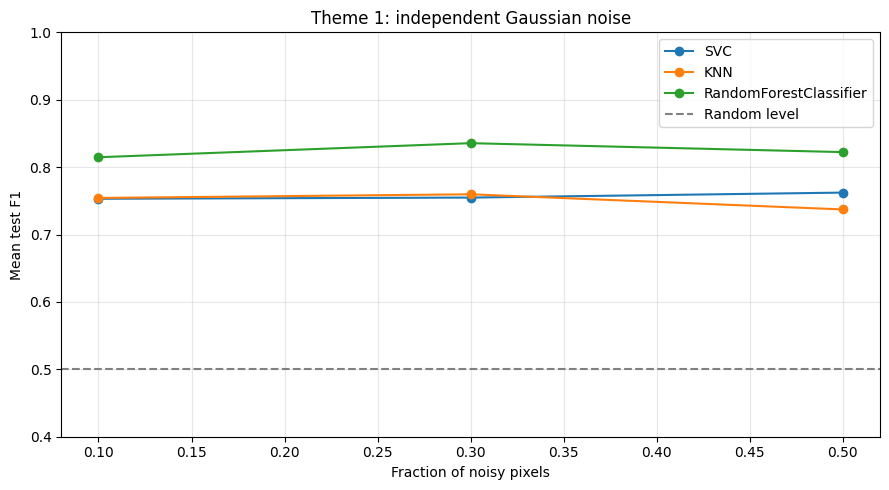

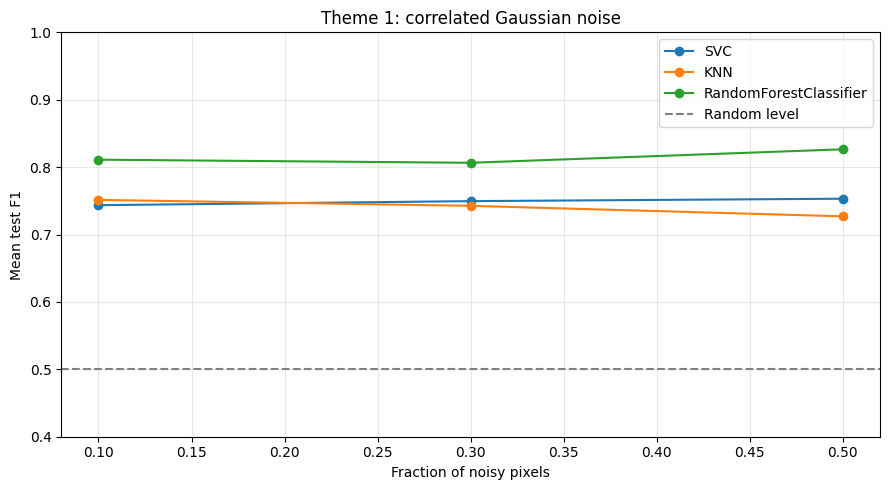

In [13]:
def run_one_part2_split(X, y, random_seed, noise_type, noise_fraction):
    X_train_original, X_test_original, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=random_seed
    )

    if noise_fraction == 0:
        X_train = X_train_original.copy()
        X_test = X_test_original.copy()
    elif noise_type == "independent":
        X_train, noise_pixels = add_independent_noise(
            X_train_original,
            noise_fraction,
            random_seed=random_seed
        )
        X_test = add_independent_noise_to_pixels(
            X_test_original,
            noise_pixels,
            random_seed=random_seed + 1000
        )
    else:
        X_train, noise_pixels = add_correlated_noise(
            X_train_original,
            noise_fraction,
            random_seed=random_seed
        )
        X_test = add_correlated_noise_to_pixels(
            X_test_original,
            noise_pixels,
            random_seed=random_seed + 2000
        )

    cv = StratifiedKFold(
        n_splits=2,
        shuffle=True,
        random_state=random_seed
    )

    models = get_model_pipelines(random_seed)
    rows = []

    for model_name, model_info in models.items():
        print("Running:", noise_type, noise_fraction, model_name)

        opt = RandomizedSearchCV(
            model_info["pipeline"],
            param_distributions=model_info["params"],
            n_iter=3,
            cv=cv,
            scoring="f1",
            n_jobs=2
        )

        opt.fit(X_train, y_train)
        y_pred = opt.predict(X_test)

        filter_mask = opt.best_estimator_.named_steps["filter"].get_support()
        if "embedded" in opt.best_estimator_.named_steps:
            embedded_mask = opt.best_estimator_.named_steps["embedded"].get_support()
            final_mask = get_full_pixel_mask(filter_mask, embedded_mask)
        else:
            final_mask = filter_mask

        rows.append({
            "random_seed": random_seed,
            "noise_type": noise_type,
            "noise_fraction": noise_fraction,
            "model": model_name,
            "cv_f1": opt.best_score_,
            "test_f1": f1_score(y_test, y_pred),
            "test_accuracy": accuracy_score(y_test, y_pred),
            "filter_k": opt.best_params_["filter__k"],
            "n_final_pixels": int(final_mask.sum()),
            "best_params": opt.best_params_,
        })

    return pd.DataFrame(rows)
all_part2_results = []

for noise_type in noise_types:
    for noise_fraction in noise_fractions:
        for seed in random_seeds:
            result_df = run_one_part2_split(
                images,
                labels,
                random_seed=seed,
                noise_type=noise_type,
                noise_fraction=noise_fraction
            )

            all_part2_results.append(result_df)

part2_results = pd.concat(all_part2_results, ignore_index=True)
part2_results.head()

part2_summary = (
    part2_results
    .groupby(["noise_type", "noise_fraction", "model"], as_index=False)
    .agg(
        mean_cv_f1=("cv_f1", "mean"),
        mean_test_f1=("test_f1", "mean"),
        sd_test_f1=("test_f1", "std"),
        mean_test_accuracy=("test_accuracy", "mean"),
        mean_filter_k=("filter_k", "mean"),
        mean_final_pixels=("n_final_pixels", "mean")
    )
    .sort_values(["noise_type", "noise_fraction", "mean_test_f1"])
)

part2_summary.round(4)

for noise_type in noise_types:
    plot_df = part2_summary[part2_summary["noise_type"] == noise_type]

    plt.figure(figsize=(9, 5))

    for model_name in plot_df["model"].unique():
        model_df = plot_df[plot_df["model"] == model_name]

        plt.plot(
            model_df["noise_fraction"],
            model_df["mean_test_f1"],
            marker="o",
            label=model_name
        )

    plt.axhline(0.5, color="gray", linestyle="--", label="Random level")
    plt.xlabel("Fraction of noisy pixels")
    plt.ylabel("Mean test F1")
    plt.title(f"Theme 1: {noise_type} Gaussian noise")
    plt.ylim(0.4, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
breakdown_rows = []

for noise_type in noise_types:
    for model_name in part2_summary["model"].unique():
        model_df = part2_summary[
            (part2_summary["noise_type"] == noise_type)
            & (part2_summary["model"] == model_name)
        ].sort_values("noise_fraction")

        bad_rows = model_df[model_df["mean_test_f1"] < 0.60]

        if len(bad_rows) == 0:
            breakdown = "not below 0.60"
        else:
            breakdown = bad_rows.iloc[0]["noise_fraction"]

        breakdown_rows.append({
            "noise_type": noise_type,
            "model": model_name,
            "breakdown_noise_fraction": breakdown
        })

breakdown_df = pd.DataFrame(breakdown_rows)
breakdown_df

,noise_type,model,breakdown_noise_fraction
0,independent,SVC,not below 0.60
1,independent,KNN,not below 0.60
2,independent,RandomForestClassifier,not below 0.60
3,correlated,SVC,not below 0.60
4,correlated,KNN,not below 0.60
5,correlated,RandomForestClassifier,not below 0.60
